In [3]:
#dataframes
import pandas as pd

import sys
sys.path.append('../../')
import odor_statistics_lib as osm

#speedup
import multiprocessing as mp

#suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.TimeSeries = pd.Series 

#math
import numpy as np
from scipy.spatial.distance import cdist
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import kurtosis
import copy


#plots
import pylab as plt
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib
from figurefirst import FigureLayout,mpl_functions
import figurefirst
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import make_axes_locatable # for colorbar
import seaborn as sns
sns.set()
sns.set_style("whitegrid")
import figurefirst as fifi
from IPython.display import display,SVG

#misc
import itertools
np.set_printoptions(suppress=True)

FS=7
dir = '~/DataAnalysis/data/Sprints/HighRes/'

In [4]:
def get_timed_rows(dataframe,duration_of_encounters):
    x = dataframe.sample(1)
    A = x.mean_time.values.round(0) - duration_of_encounters
    B = x.mean_time.values.round(0)
    timed_rows = dataframe.loc[(dataframe.mean_time > A[0]) & (dataframe.mean_time < B[0])]
    return timed_rows
    
def get_timed_encounter_stats(dataframe, distance_class, duration_of_encounters):
    df_q = dataframe.query('type == ' + str(distance_class))   
    df_q.reset_index(inplace=True, drop=True)     
            
    Nrows = get_timed_rows(df_q,duration_of_encounters)
    avg_dist = np.mean(Nrows.avg_dist_from_source)
    mean_time_whiff=np.mean(Nrows.mean_time)
#     mean_conc=np.mean(Nrows_cont.odor)
    pack_data=np.vstack([Nrows.mean_concentration,Nrows.mean_ef,Nrows.log_whiff,Nrows.whiff_ma,Nrows.std_whiff])
    return pack_data,avg_dist,len(Nrows),mean_time_whiff


def gather_stat_timed(dataframe, distance_class, duration_of_encounters,X,y,D,N,T):
    for i in range(500):
        xx,dx,n,t=get_timed_encounter_stats(dataframe,
                                               distance_class, duration_of_encounters)
        X.append(xx)
        D.append(dx)
        y.append(distance_class)
        N.append(n)
        T.append(t)
        
    return X,y,D,N,T


def create_class_column(dataframe):
    dataframe.loc[dataframe.avg_dist_from_source < 5, 'type'] = 0
    dataframe.loc[(dataframe.avg_dist_from_source >= 5)  & (dataframe.avg_dist_from_source < 30), 'type'] = 1
    dataframe.loc[dataframe.avg_dist_from_source >= 30, 'type'] = 2
    return dataframe

def get_statistics(df,index,fdf):
    osm.avg_distance(df,index,fdf)
    osm.mean_conc(df,index,fdf)
    osm.motion_statistics(df,index,fdf)
    osm.whiff_blank_duration(df,index,fdf)
    osm.trajectory_speed(df,index,fdf)
    osm.encounter_frequency(df,index,fdf,1,2)
    osm.mean_avg(df,index,fdf)
    osm.mean_t(df,index,fdf)
    osm.std_whiff(df,index,fdf)

def calc_val(X):
    return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])

In [30]:
def __kalman_forward_update__(xhat_fm, P_fm, y, u, A, B, C, R, Q):
    """
    :param xhat_fm:
    :param P_fm:
    :param y:
    :param u:
    :param A:
    :param B:
    :param C:
    :param R:
    :param Q:
    :return:
    """
    
    
    I = np.array(np.eye(A.shape[0]))
    gammaW = np.array(np.eye(A.shape[0]))

    K_f = P_fm@C.T@np.linalg.pinv(C@P_fm@C.T + R)

    if y is not None:
        new_info = (y - C@xhat_fm)
        new_info[np.isnan(new_info)] = 0
        xhat_fp = xhat_fm + K_f@new_info
        
        P_fp = (I - K_f@C)@P_fm
        xhat_fm = A@xhat_fp + B@u
        P_fm = A@P_fp@A.T + gammaW@Q@gammaW.T
        
    return xhat_fp, xhat_fm, P_fp, P_fm


def __kalman_forward_filter__(xhat_fm, P_fm, y, u, A, B, C, R, Q):
    """
    :param xhat_fm:
    :param P_fm:
    :param y:
    :param u:
    :param A:
    :param B:
    :param C:
    :param R:
    :param Q:
    :return:
    """
    if u is None:
        u = np.array(np.zeros([B.shape[1], y.shape[1]]))

    xhat_fp = None
    P_fp = []
    P_fm = [P_fm]

    for i in range(y.shape[1]):
        _xhat_fp, _xhat_fm, _P_fp, _P_fm = __kalman_forward_update__(xhat_fm[:, [-1]], P_fm[-1], y[:, [i]], u[:, [i]],
                                                                     A, B, C, R, Q)
        
        if xhat_fp is None:
            xhat_fp = _xhat_fp
        else:
            xhat_fp = np.hstack((xhat_fp, _xhat_fp))
        xhat_fm = np.hstack((xhat_fm, _xhat_fm))

        P_fp.append(_P_fp)
        P_fm.append(_P_fm)

    return xhat_fp, xhat_fm, P_fp, P_fm


def __kalman_backward_smooth__(xhat_fp, xhat_fm, P_fp, P_fm, A):
    """
    :param xhat_fp:
    :param xhat_fm:
    :param P_fp:
    :param P_fm:
    :param A:
    :return:
    """
    N = xhat_fp.shape[1]

    xhat_smooth = copy.copy(xhat_fp)
    P_smooth = copy.copy(P_fp)
    for t in range(N-2, -1, -1):
        L = P_fp[t]@A.T@np.linalg.pinv(P_fm[t])
        xhat_smooth[:, [t]] = xhat_fp[:, [t]] + L@(xhat_smooth[:, [t+1]] - xhat_fm[:, [t+1]])
        P_smooth[t] = P_fp[t] - L@(P_smooth[t+1] - P_fm[t+1])

    return xhat_smooth, P_smooth


def klm_cal(data1,data2):
    wind_vector = np.vstack((data_2.U.values, data_2.V.values)).T
    wind_magnitude = np.linalg.norm(wind_vector, axis=1)
    unit_wind_vector = wind_vector / np.vstack((wind_magnitude, wind_magnitude)).T


    velocity_vector = np.vstack((data_2.ground_speed_x.values, data_2.ground_speed_y.values)).T

    # There is probably a more efficient syntax
    velocity_ground_relative_to_wind = [np.dot(velocity_vector[i,:], unit_wind_vector[i,:]) for i in range(len(velocity_vector))]

    data_for_kf_original = pd.DataFrame({'time': data_2.time, 
                                    'velocity_ground_relative_to_wind': velocity_ground_relative_to_wind,
                                    'distance_true': data_2.distance_from_source,
                                    'distance_odor_observed': np.nan*np.ones_like(velocity_ground_relative_to_wind)})
    # kalman filter is slow, let's subsample the data
    data_for_kf = copy.copy( data_for_kf_original[::20] )
    # put distance from odor predictions in the right places
    for ix_odor in data_1.index:
        ix_kf = np.argmin( np.abs(data_1.mean_whiff_time[ix_odor] - data_for_kf.time))
        data_for_kf.distance_odor_observed.iloc[ix_kf] = data_1.predicted_distance.loc[ix_odor]
    #     print(data_for_kf.distance_odor_observed[ix_kf])

    dt = np.median(np.diff(data_for_kf.time.values))
    y = np.array([data_for_kf.distance_odor_observed.values, 
                  data_for_kf.velocity_ground_relative_to_wind.values])

    ### Define dynamics: assume constant velocity

    # constant velocity
    A = np.array([[1, dt], [0, 1]])

    # no explicit control inputs
    B = np.array([[0], [0]])

    # we have measurements of distance and velocity
    C = np.array([[1, 0], [0, 1]])


    ### Define covariances
    # measurement covariances: the measurements of the observed distance are worse than the velocity measurements
    # R = np.array([[1e-1, 0], [0, 1e-3]])
    R = np.array([[1e-2, 0], [0, 1e-3]]) #Forest

    # model covariances: the model for constant velocity is probably worse than the model for distance = integral of velocity
    # Q = np.array([[1e-3, 0], [0, 1e-1]])
    Q = np.array([[1e-2, 0], [0, 1]]) #Forest

    ### Define initial conditions
    x0 = np.array([[0], [0]])
    P0 = np.array(100*np.eye(2))
    u = None # control input -- technically this could be the acceleration, but not needed

    ### Choose a subset of the measurements for testing
    ix_start = 0
    ix_end = 100000

    y_subset = copy.copy( y[:, ix_start:ix_end] )
    y_subset[0,0] = 5 # start with a guess for initial distance (can't be nan)

    time = data_for_kf.time[ix_start:ix_end].values

    ### Run the filter and smoother
    xhat_fp, xhat_fm, P_fp, P_fm = __kalman_forward_filter__(x0, P0, y_subset, u, A, B, C, R, Q)
    xhat_smooth, _ = __kalman_backward_smooth__(xhat_fp, xhat_fm, P_fp, P_fm, A)
    return xhat_smooth, time, data_for_kf

def klm_cal_forest(data1,data2):
    wind_vector = np.vstack((data_2.U.values, data_2.V.values)).T
    wind_magnitude = np.linalg.norm(wind_vector, axis=1)
    unit_wind_vector = wind_vector / np.vstack((wind_magnitude, wind_magnitude)).T


    velocity_vector = np.vstack((data_2.ground_speed_x.values, data_2.ground_speed_y.values)).T

    # There is probably a more efficient syntax
    velocity_ground_relative_to_wind = [np.dot(velocity_vector[i,:], unit_wind_vector[i,:]) for i in range(len(velocity_vector))]

    data_for_kf_original = pd.DataFrame({'time': data_2.time, 
                                    'velocity_ground_relative_to_wind': velocity_ground_relative_to_wind,
                                    'distance_true': data_2.distance_from_source,
                                    'distance_odor_observed': np.nan*np.ones_like(velocity_ground_relative_to_wind)})
    # kalman filter is slow, let's subsample the data
    data_for_kf = copy.copy( data_for_kf_original[::20] )
    # put distance from odor predictions in the right places
    for ix_odor in data_1.index:
        ix_kf = np.argmin( np.abs(data_1.mean_whiff_time[ix_odor] - data_for_kf.time))
        data_for_kf.distance_odor_observed.iloc[ix_kf] = data_1.predicted_distance.loc[ix_odor]
    #     print(data_for_kf.distance_odor_observed[ix_kf])

    dt = np.median(np.diff(data_for_kf.time.values))
    y = np.array([data_for_kf.distance_odor_observed.values, 
                  data_for_kf.velocity_ground_relative_to_wind.values])

    ### Define dynamics: assume constant velocity

    # constant velocity
    A = np.array([[1, dt], [0, 1]])

    # no explicit control inputs
    B = np.array([[0], [0]])

    # we have measurements of distance and velocity
    C = np.array([[1, 0], [0, 1]])


    ### Define covariances
    # measurement covariances: the measurements of the observed distance are worse than the velocity measurements
    R = np.array([[1e-2, 0], [0, 1e-3]]) #Forest

    # model covariances: the model for constant velocity is probably worse than the model for distance = integral of velocity
    Q = np.array([[1e-2, 0], [0, 1]]) #Forest

    ### Define initial conditions
    x0 = np.array([[0], [0]])
    P0 = np.array(100*np.eye(2))
    u = None # control input -- technically this could be the acceleration, but not needed

    ### Choose a subset of the measurements for testing
    ix_start = 0
    ix_end = 100000

    y_subset = copy.copy( y[:, ix_start:ix_end] )
    y_subset[0,0] = 5 # start with a guess for initial distance (can't be nan)

    time = data_for_kf.time[ix_start:ix_end].values

    ### Run the filter and smoother
    xhat_fp, xhat_fm, P_fp, P_fm = __kalman_forward_filter__(x0, P0, y_subset, u, A, B, C, R, Q)
    xhat_smooth, _ = __kalman_backward_smooth__(xhat_fp, xhat_fm, P_fp, P_fm, A)
    return xhat_smooth, time, data_for_kf

In [19]:
# d1=pd.read_hdf(dir+'Windy/WindyMASigned.h5')
# d2=pd.read_hdf(dir+'NotWindy/NotWindyMASigned.h5')
# d3=pd.read_hdf(dir+'Forest/ForestMASigned.h5')
# trainset=pd.concat([d1,d2,d3])
# trainset = trainset.reset_index(drop=True)

In [31]:
lookback_time = 10
# filters=[1,2,4,6,8]
filters = [1,2,4,6,8]

m_error = []

for i in range(len(filters)):
    # print(filters[i])
    d1=pd.read_hdf(dir+'Windy/WindyMASigned.h5')
    d2=pd.read_hdf(dir+'NotWindy/NotWindyMASigned.h5')
    d3=pd.read_hdf(dir+'Forest/ForestMASigned.h5')
    trainset=pd.concat([d1,d2,d3])
    trainset = trainset.reset_index(drop=True)
    # trainset=pd.read_hdf(dir+'Forest/ForestMASigned.h5')
    data_2=d3.copy()

    ## calulcate statistics
    np.seterr(divide = 'ignore') 
    index = osm.get_index(trainset,filters[i])
    fdf = pd.DataFrame()
    get_statistics(trainset,index,fdf)
    stat_cal_set=create_class_column(fdf)
    print(len(fdf))
    ## calculate statistics
    D_train=[]
    mean_time_train=[]
    Xtrain = []
    ytrain = []
    Nrows_train = []

    for distance_class in [0,1,2]:
        Xtrain, ytrain, D_train,Nrows_train,mean_time_train = gather_stat_timed(stat_cal_set,distance_class,
                          lookback_time, Xtrain,ytrain,D_train,Nrows_train,
                          mean_time_train)
    # column_names=['mc_mean','ma_std_dev','ma_max','wd_std_dev'] #aicfiltered params
    column_names=['mc_min','mc_max','mc_mean','mc_std_dev','mc_k',
                 'wf_min','wf_max','wf_mean','wf_std_dev','wf_k',
                 'wd_min','wd_max','wd_mean','wd_std_dev','wd_k',
                 'ma_min','ma_max','ma_mean','ma_std_dev','ma_k',
                 'st_min','st_max','st_mean','st_std_dev','st_k']

    traindf=pd.DataFrame(columns = column_names)
    c1=[]
    for i in range(len(Xtrain)):
        if(np.size(Xtrain[i])==0):
            c1.append(i)
            continue
        else:
            X=[]
            for j in range(len(Xtrain[i])):
                X.append(calc_val(Xtrain[i][j]))
            traindf.loc[i]=np.ravel(X)

    traindf['distance']=np.delete(D_train, c1)
    traindf['mean_whiff_time'] = np.delete(mean_time_train, c1)

    y=traindf.distance
    x=traindf.loc[traindf.distance.notnull(), column_names].values
    x =sm.add_constant(x)
    x[np.isnan(x)] =0
    # # model1=smf.ols(formula=""" distance ~ mc_mean + ma_std_dev + ma_max + wd_std_dev """, data=traindf).fit()
    olsmod = sm.OLS(y, x).fit()
    # olsres = olsmod.fit()
    
    # print("\n ================>",olsmod.rsquared)
    ypred = olsmod.predict(x)
    traindf['predicted_distance']=ypred

    data_1=traindf.copy()
    xhat_smooth,time,data_for_kf = klm_cal(data_1,data_2)
    error = xhat_smooth[0,:] - data_for_kf.distance_true.values

    median_error = np.median(np.abs(error))
    m_error.append(median_error)
    # print(olsres.rsquared)

    # lpf.append(olsres.rsquared)    
    
# print('done')
# lpdf=pd.DataFrame()
# lpdf['threshold']=filters
# lpdf['rsquared']=lpf

/home/vbl/DataAnalysis/odor_analysis/data_exploration/figure/review/../../odor_statistics_lib.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.efreq.iloc[start] = 1


12714


/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when 

13017


/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when 

...

/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when 

10972


/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when 

10269


/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.ravel([np.min(X),np.max(X),np.mean(X),np.std(X),kurtosis(X)])
/tmp/ipykernel_7014/3950402808.py:51: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when 

In [32]:
m_error #hws

[6.798159502550998,
 7.179494085023178,
 7.0831100083957494,
 6.817139938156103,
 6.9193831886628585]

In [22]:
# median_error_df=pd.DataFrame()
# median_error_df['threshold']=filters

In [33]:
median_error_df['median_error_forest']  = m_error

In [37]:
median_error_df

,threshold,median_error_hws,median_error_lws,median_error_forest
0,1,5.219664,8.624174,6.798160
1,2,4.728373,6.845887,7.179494
2,4,4.079809,7.086735,7.083110
3,6,4.954383,6.683484,6.817140
4,8,5.292285,6.630956,6.919383


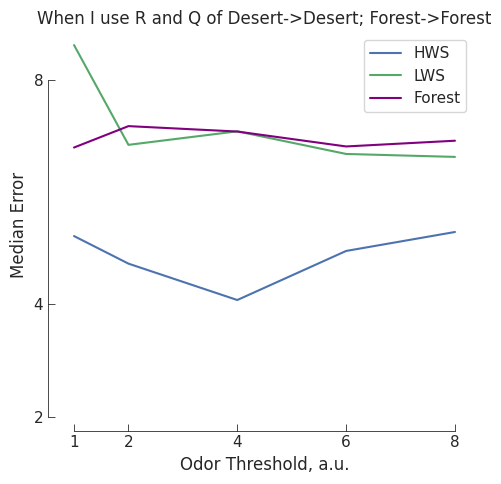

In [36]:
f,ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(median_error_df.threshold,median_error_df.median_error_hws,c ='b', label='HWS')
ax.plot(median_error_df.threshold,median_error_df.median_error_lws,c='g', label='LWS')
ax.plot(median_error_df.threshold,median_error_df.median_error_forest,c='purple', label='Forest')

mpl_functions.adjust_spines(ax,['left','bottom'],
                            spine_locations={'left': 5}, 
                            smart_bounds=True,   
                            xticks=[1,2,4,6,8],
                            yticks=[2,4,8],
                            linewidth=0.5)

# ax.axvline(2, color='r', linestyle='--', linewidth=1)

ax.set_xlabel('Odor Threshold, a.u.')
ax.set_ylabel('Median Error')
ax.grid(False)
ax.legend(loc='best')
ax.set_title('When I use R and Q of Desert->Desert; Forest->Forest')
f.tight_layout()
# ax.set_fontsize(14)

In [82]:
def process_filter(threshold):

    dir = '~/DataAnalysis/data/Sprints/HighRes/'
    trainset = pd.read_hdf(dir + 'Windy/WindyMASigned.h5')
    data_2 = trainset.copy()

    np.seterr(divide='ignore') 
    index = osm.get_index(trainset, threshold)
    fdf = pd.DataFrame()
    get_statistics(trainset, index, fdf)
    stat_cal_set = create_class_column(fdf)

    D_train, mean_time_train, Xtrain, ytrain, Nrows_train = [], [], [], [], []

    for distance_class in [0, 1]:
        Xtrain, ytrain, D_train, Nrows_train, mean_time_train = gather_stat_timed(
            stat_cal_set, distance_class, lookback_time, Xtrain, ytrain, D_train, Nrows_train, mean_time_train)

    column_names = ['mc_min', 'mc_max', 'mc_mean', 'mc_std_dev', 'mc_k',
                    'wf_min', 'wf_max', 'wf_mean', 'wf_std_dev', 'wf_k',
                    'wd_min', 'wd_max', 'wd_mean', 'wd_std_dev', 'wd_k',
                    'ma_min', 'ma_max', 'ma_mean', 'ma_std_dev', 'ma_k',
                    'st_min', 'st_max', 'st_mean', 'st_std_dev', 'st_k']
                    
    traindf = pd.DataFrame(columns=column_names)
    c1 = []
    for i in range(len(Xtrain)):
        if np.size(Xtrain[i]) == 0:
            c1.append(i)
        else:
            X = [calc_val(Xtrain[i][j]) for j in range(len(Xtrain[i]))]
            traindf.loc[i] = np.ravel(X)

    traindf['distance'] = np.delete(D_train, c1)
    traindf['mean_whiff_time'] = np.delete(mean_time_train, c1)

    y = traindf.distance
    x = traindf.loc[traindf.distance.notnull(), column_names].values
    x = sm.add_constant(x)
    x[np.isnan(x)] = 0
    olsmod = sm.OLS(y, x).fit()

    ypred = olsmod.predict(x)
    traindf['predicted_distance'] = ypred

    # model_formula = "distance ~ mc_mean + ma_std_dev + ma_max + wd_std_dev"
    # model = smf.ols(formula=model_formula, data=traindf).fit()
    # traindf['predicted_distance'] = model.predict(traindf)

    data_1 = traindf.copy()
    xhat_smooth, time, data_for_kf = klm_cal(data_1, data_2)
    error = xhat_smooth[0, :] - data_for_kf.distance_true.values

    median_error = np.median(np.abs(error))
    # return median_error, olsmod.rsquared
    return median_error

def main():
    lookback_time = 10
    filters = [1, 2, 4]
    
    with mp.Pool(processes=mp.cpu_count()-4) as pool:
        results = pool.map(process_filter, filters)
    
    # m_error, rsquared_values = zip(*results)
    # m_error=results
    print("Median Errors:", results)
    # print("R-squared values:", rsquared_values)
    
    # Optional: Save results to DataFrame and then to file
    # df_results = pd.DataFrame({
    #     'filter': filters,
    #     'median_error': m_error,
    #     'rsquared': rsquared_values
    # })
    # print(df_results)

if __name__ == '__main__':
    main()

/home/vbl/DataAnalysis/odor_analysis/data_exploration/figure/review/../../odor_statistics_lib.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.efreq.iloc[start] = 1
/home/vbl/DataAnalysis/odor_analysis/data_exploration/figure/review/../../odor_statistics_lib.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.efreq.iloc[start] = 1
/home/vbl/DataAnalysis/odor_analysis/data_exploration/figure/review/../../odor_statistics_lib.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

Median Errors: [2.539226463676668, 2.539226463676668, 2.539226463676668]


In [71]:
m_error

[4.101136495944615,
 4.451808505734457,
 4.751202847645538,
 5.242118826968236,
 4.938442626477247]

In [28]:
# median_error_df=pd.DataFrame()
# median_error_df['threshold']=filters

In [38]:
median_error_df

,threshold,median_error_hws,median_error_lws,median_error_forest
0,1,5.219664,8.624174,6.798160
1,2,4.728373,6.845887,7.179494
2,4,4.079809,7.086735,7.083110
3,6,4.954383,6.683484,6.817140
4,8,5.292285,6.630956,6.919383


In [47]:
median_error_df.to_hdf('~/DataAnalysis/data/Sprints/HighRes/review/median_error_klm.h5', key='df', mode='w')

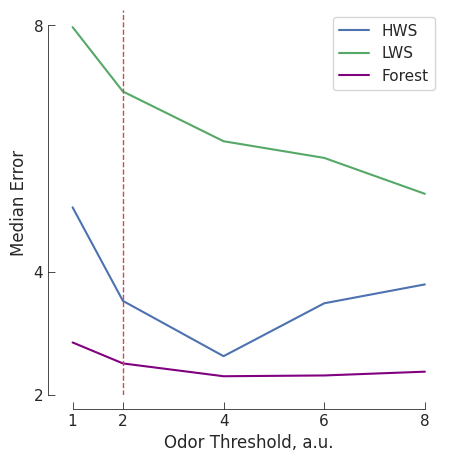

In [46]:
f,ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(median_error_df.threshold,median_error_df.median_error_hws,c ='b', label='HWS')
ax.plot(median_error_df.threshold,median_error_df.median_error_lws,c='g', label='LWS')
ax.plot(median_error_df.threshold,median_error_df.median_error_forest,c='purple', label='Forest')

mpl_functions.adjust_spines(ax,['left','bottom'],
                            spine_locations={'left': 5}, 
                            smart_bounds=True,   
                            xticks=[1,2,4,6,8],
                            yticks=[2,4,8],
                            linewidth=0.5)

ax.axvline(2, color='r', linestyle='--', linewidth=1)

ax.set_xlabel('Odor Threshold, a.u.')
ax.set_ylabel('Median Error')
ax.grid(False)
ax.legend(loc='best')
# ax.set_fontsize(14)

In [195]:
lookback_time = 10
filters = [1, 2, 4, 6, 8]

def calculate_statistics(filter_val):
    # Load data
    # trainset = pd.read_hdf(dir+'Forest/ForestMASigned.h5')
    trainset = pd.read_hdf(dir+'Forest/ForestMASigned.h5')
    np.seterr(divide='ignore')
    
    # Get index and perform statistics
    index = osm.get_index(trainset, filter_val)
    fdf = pd.DataFrame()
    get_statistics(trainset, index, fdf)
    stat_cal_set = create_class_column(fdf)

    # Gather statistics
    Xtrain, ytrain, D_train, Nrows_train, mean_time_train = [], [], [], [], []
    for distance_class in [0,1]:
        Xtrain, ytrain, D_train, Nrows_train, mean_time_train = gather_stat_timed(
            stat_cal_set, distance_class, lookback_time, Xtrain, ytrain, D_train, Nrows_train, mean_time_train
        )

    column_names = [
        'mc_min', 'mc_max', 'mc_mean', 'mc_std_dev', 'mc_k',
        'wf_min', 'wf_max', 'wf_mean', 'wf_std_dev', 'wf_k',
        'wd_min', 'wd_max', 'wd_mean', 'wd_std_dev', 'wd_k',
        'ma_min', 'ma_max', 'ma_mean', 'ma_std_dev', 'ma_k',
        'st_min', 'st_max', 'st_mean', 'st_std_dev', 'st_k'
    ]
    traindf = pd.DataFrame(columns=column_names)
    c1 = []
    for i in range(len(Xtrain)):
        if np.size(Xtrain[i]) == 0:
            c1.append(i)
        else:
            X = [calc_val(Xtrain[i][j]) for j in range(len(Xtrain[i]))]
            traindf.loc[i] = np.ravel(X)

    traindf['distance'] = np.delete(D_train, c1)
    traindf['mean_whiff_time'] = np.delete(mean_time_train, c1)


    models = {
        'mc_mean': smf.ols(formula="distance ~ mc_mean", data=traindf).fit(),
        'wf_mean': smf.ols(formula="distance ~ wf_mean", data=traindf).fit(),
        'wd_mean': smf.ols(formula="distance ~ wd_mean", data=traindf).fit(),
        'ma_mean': smf.ols(formula="distance ~ ma_mean", data=traindf).fit(),
        'st_mean': smf.ols(formula="distance ~ st_mean", data=traindf).fit()
    }
    r2_values = {key: model.rsquared for key, model in models.items()}
    return (filter_val, r2_values)

# Multiprocessing setup
pool = mp.Pool(mp.cpu_count())
results = pool.map(calculate_statistics, filters)
pool.close()
pool.join()

# Store results in DataFrame
individual_r2_df = pd.DataFrame(columns=[f'threshold_{f}' for f in filters])
for filter_val, r2_values in results:
    individual_r2_df = pd.concat([individual_r2_df, pd.DataFrame([r2_values], index=[f'threshold_{filter_val}'])])

individual_r2_df = individual_r2_df.T  # Transpose for desired format
print(individual_r2_df)

/home/vbl/DataAnalysis/odor_analysis/data_exploration/figure/review/../../odor_statistics_lib.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.efreq.iloc[start] = 1
/home/vbl/DataAnalysis/odor_analysis/data_exploration/figure/review/../../odor_statistics_lib.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.efreq.iloc[start] = 1
/home/vbl/DataAnalysis/odor_analysis/data_exploration/figure/review/../../odor_statistics_lib.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

            threshold_1 threshold_2 threshold_4 threshold_6 threshold_8
threshold_1         NaN         NaN         NaN         NaN         NaN
threshold_2         NaN         NaN         NaN         NaN         NaN
threshold_4         NaN         NaN         NaN         NaN         NaN
threshold_6         NaN         NaN         NaN         NaN         NaN
threshold_8         NaN         NaN         NaN         NaN         NaN
mc_mean        0.320832    0.268028    0.209447     0.25478    0.094602
wf_mean        0.000127    0.014029    0.001959    0.003609    0.000442
wd_mean        0.030361    0.019837    0.011856    0.025176    0.009619
ma_mean        0.044804    0.043674    0.000033    0.000045    0.007326
st_mean        0.314441    0.230725    0.116286    0.078634    0.005336


In [ ]:
# individual_r2_df['threshold_1'] = individual_r2
# individual_r2_df = pd.DataFrame()
# individual_r2_df.to_hdf('~/DataAnalysis/data/Sprints/HighRes/individual_r2_hws.h5', key='df', mode='w')

In [196]:
individual_r2_df = individual_r2_df.dropna()
individual_r2_df = individual_r2_df.reset_index(drop=True)
individual_r2_df 

,threshold_1,threshold_2,threshold_4,threshold_6,threshold_8
0,0.320832,0.268028,0.209447,0.25478,0.094602
1,0.000127,0.014029,0.001959,0.003609,0.000442
2,0.030361,0.019837,0.011856,0.025176,0.009619
3,0.044804,0.043674,0.000033,0.000045,0.007326
4,0.314441,0.230725,0.116286,0.078634,0.005336


In [50]:
individual_r2_df = pd.read_hdf('~/DataAnalysis/data/Sprints/HighRes/review/individual_r2_hws.h5')

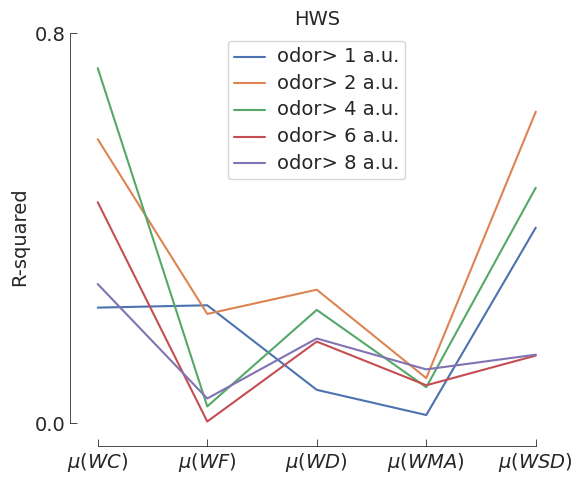

In [53]:
f,ax = plt.subplots(1,1,figsize=(6,5))
ax.plot(individual_r2_df.index, individual_r2_df.threshold_1, label='odor> 1 a.u.')
ax.plot(individual_r2_df.index, individual_r2_df.threshold_2, label='odor> 2 a.u.')
ax.plot(individual_r2_df.index, individual_r2_df.threshold_4, label='odor> 4 a.u.')
ax.plot(individual_r2_df.index, individual_r2_df.threshold_6, label='odor> 6 a.u.')
ax.plot(individual_r2_df.index, individual_r2_df.threshold_8, label='odor> 8 a.u.')

mpl_functions.adjust_spines(ax,['left','bottom'],
                            spine_locations={'left':4,'bottom':5}, 
                            smart_bounds=True,
                            xticks=[0,1,2,3,4],
                            yticks = [0,0.8],
                            linewidth=0.5)

ax.set_xticklabels(['$\mu(WC)$','$\mu(WF)$','$\mu(WD)$','$\mu(WMA)$','$\mu(WSD)$'])
ax.set_ylabel('R-squared')
ax.grid(False)
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend(loc='best')
ax.set_title('HWS')
mpl_functions.set_fontsize(ax, 14)
f.tight_layout()

In [54]:
# individual_r2_df.to_hdf('~/DataAnalysis/data/Sprints/HighRes/review/individual_r2_forest.h5', key='df', mode='w')